# NN_model on solving regresseion problem with generated dataset

## Setup for saving results

### Date and Time Information
- When saving everything from model parameters to plot images, we will save its file name with the time information.

In [1]:
import datetime

# Get the current date and time
current_datetime = datetime.datetime.now()

# Format the date and time as a string
date_time_str = current_datetime.strftime("%Y%m%d_%H%M%S")

# Create the object name
object_name = f"model_reg_{date_time_str}"

# Now 'object_name' contains the desired name with date and time info
print(object_name)

model_reg_20250208_183000


### Create result folder
- We create a folder to save the model performance.
- Also, it creates a folder with assigned name if it doesn't exists.

In [2]:
import os

# Set the dataset name and define the folder name
# dataset_name = 'gen_linear/dataset_w_error'
dataset_name = 'gen_linear/dataset_mr_w_error'    # 'dataset_mr_w_error'
result_folder_name = f'save_results_' + dataset_name

# Create the folder if it doesn't exist
if not os.path.exists(result_folder_name):
    os.makedirs(result_folder_name)

In [3]:
# Set save folder directory
save_dir = result_folder_name + '/'
print('save_dir:', save_dir)

save_dir: save_results_gen_linear/dataset_mr_w_error/


# Generated dataset

## Load the generated dataset with 
- Specify the file directory of the dataset to load.

In [4]:
import numpy as np

## Load the generated dataset
file_dir = f'../'+dataset_name+'/gen_data_reg.txt'
print(file_dir)
loaded_data = np.loadtxt(file_dir, delimiter='\t')
column_names = np.array(['feature1', 'feature2', 'feature3', 'feature4', 'target'])
data = loaded_data

print(column_names)
print()
print(data[:10])

../gen_linear/dataset_mr_w_error/gen_data_reg.txt
['feature1' 'feature2' 'feature3' 'feature4' 'target']

[[ 1.94834585  0.98446658  1.93310583  2.39271643  0.51410343]
 [ 1.46862528  0.93264758  2.396144    1.92005028  0.19657342]
 [ 1.31416729  1.35245092  1.38080182  1.14863833 -0.29688942]
 [ 1.78113399  0.02507365  0.75374063  1.08823615 -0.65018823]
 [ 0.95752344  1.22904831  1.15979875  0.55650446 -0.77771362]
 [ 2.58432687  0.9371665   1.64472217  0.54871976 -0.1921613 ]
 [ 1.26499959  1.11915165  1.03902449  1.6749975  -0.1984587 ]
 [ 1.22807478  0.90153824  1.31206174  2.59867929  0.21259516]
 [ 1.61345768  0.48750733  2.0200227   0.67627322 -0.53093019]
 [ 1.75940897  0.          0.9509464   1.5631253  -0.4046954 ]]


## Split the dataset into train / test dataset

- Specify the size of the train / test datatset.

In [5]:
# Specify the size of train and test datasets
train_size = 100
test_size = 20
random_state = 42

In [6]:
# Assign X and y as features and target variables, respectively.
features = data[:, :-1]
target = data[:,-1]

# Split the dataset into train and test datasets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(features, target,
                                                    train_size = train_size, 
                                                    test_size = test_size,
                                                    # test_size=0.3,
                                                    random_state=random_state)

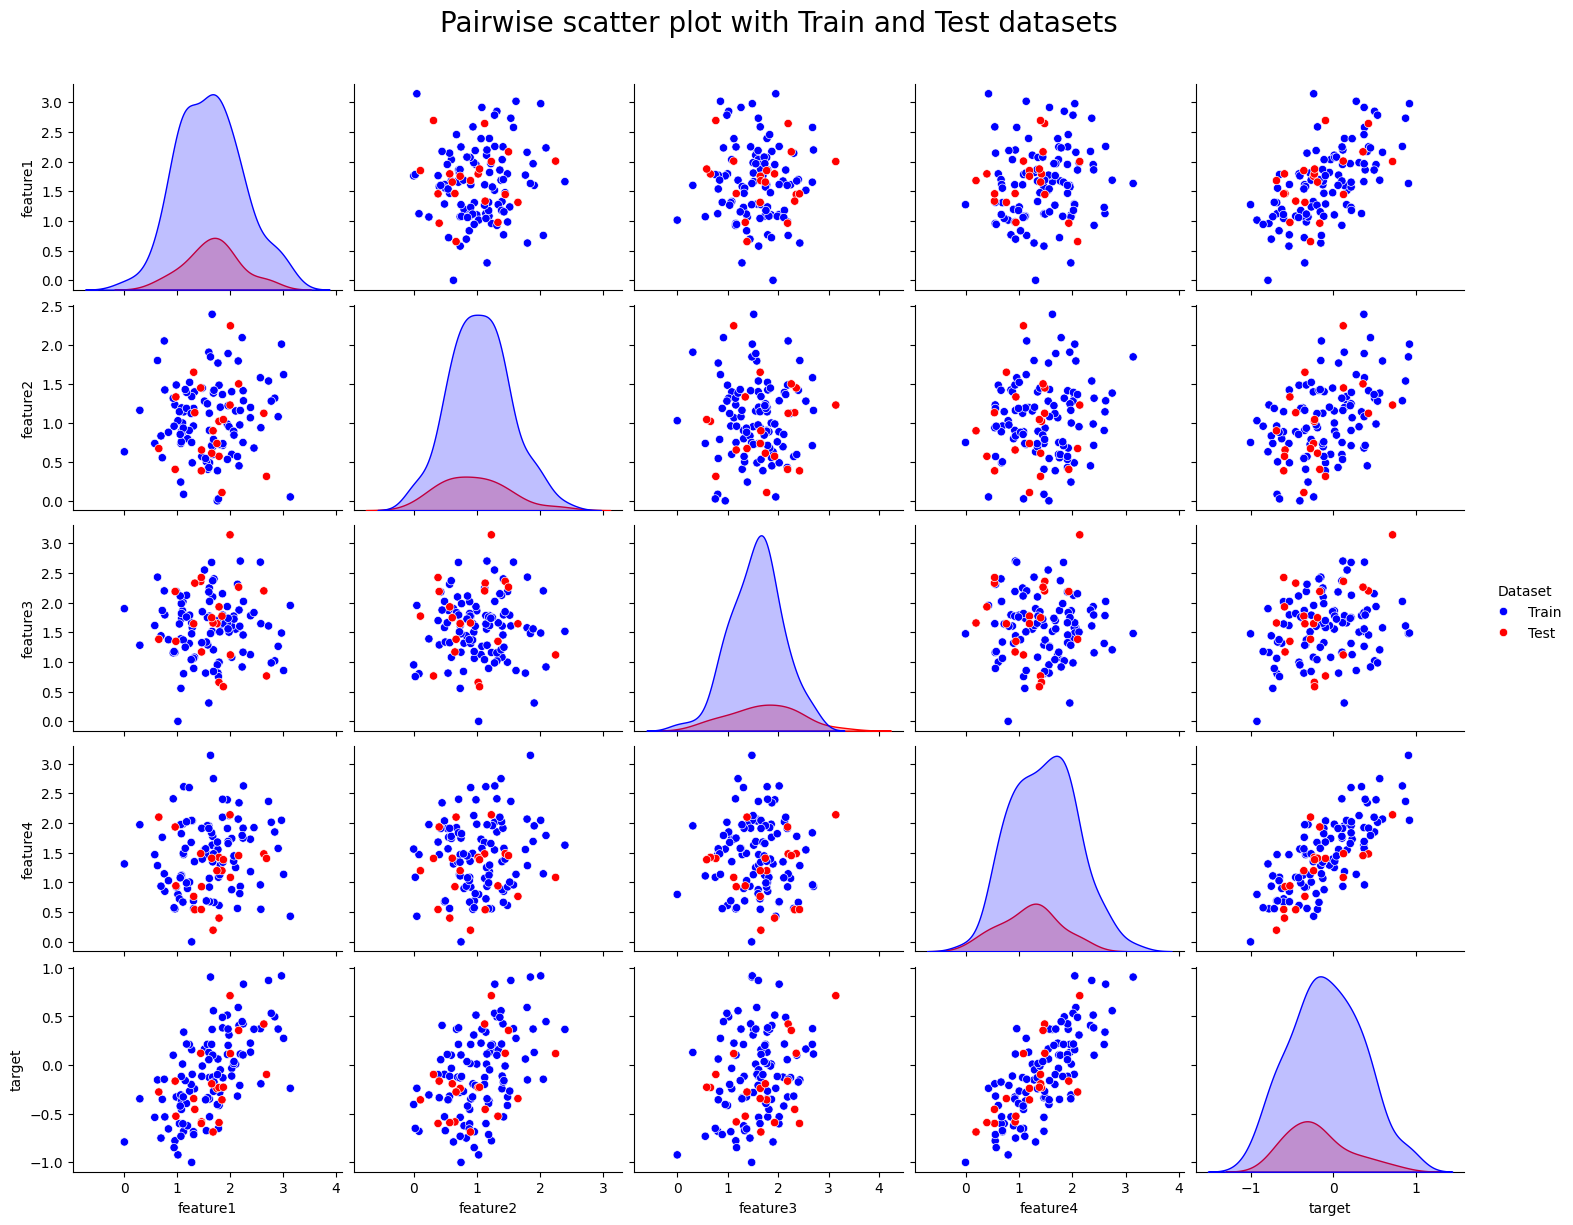

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'features' and 'target' are your initial datasets before splitting
# And you have already split them into X_train, X_test, y_train, y_test

# Combine training and testing sets back into a single DataFrame
feature_names = np.array(['feature1', 'feature2', 'feature3', 'feature4'])
train_df = pd.DataFrame(X_train, columns=feature_names)
train_df['target'] = y_train
train_df['Dataset'] = 'Train'

test_df = pd.DataFrame(X_test, columns=feature_names)
test_df['target'] = y_test
test_df['Dataset'] = 'Test'

# Combine into one DataFrame
combined_df = pd.concat([train_df, test_df], ignore_index=True)

# Plotting the pairwise scatter plot with different colors for Train and Test
scatter_plot = sns.pairplot(combined_df, hue='Dataset', height=2.5, aspect=1.2, palette=['blue', 'red'])
# Adjust the top margin of the subplots to make space for the title
plt.subplots_adjust(top=0.92)
# Add a title to the figure
plt.suptitle('Pairwise scatter plot with Train and Test datasets', fontsize=20)

# Save the figure
# plt.savefig(save_dir + 'pairwise_scatter_train_test.png')
plt.show()

## Convert NumPy dataset into PyTorch dataset for training a neural network model.

- `batch_size_train`, `batch_size_test`: both integers. Appropriately set the batch size for the train / test dataset.
- Also, **`torch.manual_seed`** is assigned here to ensure the random processes in PyTorch are reproducible.

In [8]:
# Set the batch sizes, random_seen num
batch_size_train = 10     # len(X_train)
batch_size_test = 5      # len(y_train)
torch_seed_num = 42

In [9]:
import torch
from torch import manual_seed, tensor, Tensor, float32
from torch.utils.data import Dataset, DataLoader

# Train Dataset (features, target)
# -------------

# Define your custom dataset class
class MyDataset_train(Dataset):
    def __init__(self, data, targets):
        self.data = data
        self.targets = targets

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx]


# Test Dataset (only features)
# -------------

# Define your custom dataset class
class MyDataset_test(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [10]:
# Set train shuffle seed (for reproducibility)
manual_seed(torch_seed_num)

# Convert data and labels to tensors
data_tensor = torch.tensor(X_train, dtype=torch.float)
target_tensor = torch.tensor(y_train, dtype=torch.float)

# Create an instance of your custom dataset
train_dataset = MyDataset_train(data_tensor, target_tensor)

# Define torch DataLoader with the data
train_loader = DataLoader(train_dataset, 
                          batch_size=batch_size_train,
                          shuffle=True)

In [11]:
# Set test shuffle seed (for reproducibility)
manual_seed(torch_seed_num)

# Convert test data to a tensor
test_data_tensor = torch.tensor(X_test, dtype=torch.float)
test_target_tensor = torch.tensor(y_test, dtype=torch.float)

# Create an instance of your custom dataset for test data
test_dataset = MyDataset_train(test_data_tensor, test_target_tensor)

# Define DataLoader for test data
test_batch_size = 5  # Use the batch size you prefer for testing
test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)  # No need to shuffle test data

In [12]:
# Set higher precision for printing
torch.set_printoptions(precision=10)

# Print out the `train_loader` outputs
print('----------train_loader----------')
print('- dataset features(head):')
print(train_dataset.data[0:10])
print('- dataset features shape:', train_dataset.data.shape)
print()
print('- dataset target(head):')
print(train_dataset.targets[0:10])
print('- dataset features shape:', train_dataset.targets.shape)
print()
print('-type:', train_loader)
print()
print()

# Print out the `test_loader` outputs
print('----------test_loader----------')
print('- dataset features(head):')
print(test_dataset.data[0:10])
print('- dataset features shape:', test_dataset.data.shape)
print()
print('- dataset target(head):')
print(test_dataset.targets[0:10])
print('- dataset features shape:', test_dataset.targets.shape)
print()
print('- type:', test_loader)
print()
print()

----------train_loader----------
- dataset features(head):
tensor([[1.7928965092, 1.4817720652, 0.9962972999, 0.6139598489],
        [0.6277887225, 1.7979912758, 2.4288291931, 1.2841920853],
        [1.1021288633, 0.9971833229, 1.8621724844, 1.9815551043],
        [0.9575234652, 1.2290482521, 1.1597987413, 0.5565044880],
        [1.1213353872, 0.0836626515, 0.8021435738, 1.4700576067],
        [1.5164535046, 1.2775869370, 2.5487329960, 1.5491857529],
        [2.3888156414, 1.1967122555, 1.7789696455, 1.1823261976],
        [1.1240438223, 1.1404857635, 1.7810341120, 2.6136255264],
        [2.1556355953, 1.7922434807, 1.5753610134, 2.0677425861],
        [1.5988017321, 1.9048852921, 0.3089436591, 1.9541229010]])
- dataset features shape: torch.Size([100, 4])

- dataset target(head):
tensor([-0.4148380458, -0.1519539058,  0.0109257828, -0.7777135968,
        -0.6800614595,  0.1654293984,  0.1333744824,  0.3392348886,
         0.5925785899,  0.1304036230])
- dataset features shape: torch.S

# PyTorch neural network model

## Build a PyTorch neural network model
- We define a Pytorch model class to solve the given problem.

In [13]:
import torch
import torch.nn as nn
from torch import no_grad

import matplotlib.pyplot as plt
import time

In [14]:
# Define the neural network model
class RegressionModel(nn.Module):
    def __init__(self, hidden_activation=None, output_activation=None):
        super(RegressionModel, self).__init__()
        # Define layers
        self.layer1 = nn.Linear(4, 4)
        self.layer2 = nn.Linear(4, 4)
        self.layer3 = nn.Linear(4, 4)
        self.output_layer = nn.Linear(4, 1)
        
        # Store the activation functions
        self.hidden_activation = hidden_activation
        self.output_activation = output_activation

    def forward(self, x):
        # Hidden layer
        if self.hidden_activation:
            x = self.hidden_activation(self.layer1(x))
            x = self.hidden_activation(self.layer2(x))
            x = self.hidden_activation(self.layer3(x))
        else:
            x = self.layer1(x)
            x = self.layer2(x)
            x = self.layer3(x)
        
        # Output layer
        if self.output_activation:
            x = self.output_activation(self.output_layer(x))
        else:
            x = self.output_layer(x)

        return x

- Set the appropriate hyper-parameters:
    - `num_epochs`: integer. The number of epochs
    - `hidden_acti`, `output_acti`: torch.nn object. The activation function for the hidden layers and the output layer. Both activation functions should be appropriately chosen based on the range of values in the dataset.
        - <font color="blue">None</font>: It applies the identity function, $f(x)=x$, as its activation function.
        - torch.nn.Identity(): Identity function
        - torch.relu: ReLU function (the rectified linear unit function)
        - torch.tanh: Hyperbolic tangent function
    - `optimizer`: torch.optim object. optimizer
    - `loss_func`: torch.nn object. loss function

In [15]:
# Assign the number of epochs
num_epochs = 100

# Define the activation function for the hidden layers and the output layer
hidden_acti = torch.tanh     # None, torch.relu, torch.tanh
output_acti = torch.tanh      # None, torch.tanh

# Instantiate the model for training and evaluation (on test data)
model_reg = RegressionModel(hidden_activation=hidden_acti,
                            output_activation=output_acti)
model_reg_eval = RegressionModel(hidden_activation=hidden_acti,
                                 output_activation=output_acti)

# Define loss function and optimizer
optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.001)
loss_func = nn.MSELoss()

## The structure of the PyTorch Model

In [16]:
import torch
import torchvision.models as models

# Print the model structure
print(model_reg)

RegressionModel(
  (layer1): Linear(in_features=4, out_features=4, bias=True)
  (layer2): Linear(in_features=4, out_features=4, bias=True)
  (layer3): Linear(in_features=4, out_features=4, bias=True)
  (output_layer): Linear(in_features=4, out_features=1, bias=True)
)


In [17]:
import torchsummary
## summary(model, input_size=(channels, H, W))
torchsummary.summary(model=model_reg, input_size=(1, 1, 4))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1              [-1, 1, 1, 4]              20
            Linear-2              [-1, 1, 1, 4]              20
            Linear-3              [-1, 1, 1, 4]              20
            Linear-4              [-1, 1, 1, 1]               5
Total params: 65
Trainable params: 65
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [18]:
## Save the PyTorch model summary into .txt file

import io
from contextlib import redirect_stdout

# Capture the output of print(model_reg)
model_reg_str = io.StringIO()
with redirect_stdout(model_reg_str):
    print(model_reg)

# Save to a text file
with open(save_dir+f"model_reg_str.txt", "w") as file:
    file.write("Model Structure:\n")
    file.write(model_reg_str.getvalue())

## Train a PyTorch neural network model

In [19]:
def training(model, epochs, train_loader, val_loader, optimizer, loss_func):
    # Start training
    train_loss = []
    val_loss = []
    epoch_digit_width = len(str(epochs))
    
    # Set model to training model    
    for epoch in range(epochs):
        
        model.train()
        start_train_time  = time.time()
        total_train_loss = []

        for batch_idx, (data, target) in enumerate(train_loader):
            # Assuming your data doesn't need squeezing or other preprocessing
            target = target.float().unsqueeze(1)

            optimizer.zero_grad(set_to_none=True) # Initialize gradient
            output = model(data)        # Forward pass
            loss = loss_func(output, target)      # Calculate loss
            loss.backward()                       # Backward pass
            optimizer.step()                      # Optimize weights
            total_train_loss.append(loss.item())  # Store loss
            
        train_duration = time.time() - start_train_time
        train_loss.append(sum(total_train_loss) / len(total_train_loss))

        # Validation phase
        model.eval()
        start_val_time = time.time()
        total_val_loss = []
        with torch.no_grad():
            for data, target in val_loader:
                # Same preprocessing as for training data, if necessary
                target = target.float().unsqueeze(1)
                output = model(data)
                loss = loss_func(output, target)
                total_val_loss.append(loss.item())

        val_loss.append(sum(total_val_loss) / len(val_loader))
        val_duration = time.time() - start_val_time
        
        # Print training and validation results with time duration
        print(f'Epoch: [{epoch+1:>{epoch_digit_width}}/{epochs}],  Training Loss: {train_loss[-1]:.8f},  '
              f'Validation Loss: {val_loss[-1]:.8f},  '
              f'Training Time: {train_duration:.2f}s,  '
              f'Validation Time: {val_duration:.2f}s')  # Optional: Validation Time
        
    results = {
            'train_loss': train_loss,
            'val_loss': val_loss
            }
    return results

In [20]:
model_reg_training_loss = training(model=model_reg, 
                                   epochs=num_epochs,
                                   train_loader=train_loader,
                                   val_loader=test_loader,
                                   optimizer=optimizer,
                                   loss_func=loss_func)

Epoch: [  1/100],  Training Loss: 0.28004680,  Validation Loss: 0.28062582,  Training Time: 0.01s,  Validation Time: 0.00s
Epoch: [  2/100],  Training Loss: 0.25634568,  Validation Loss: 0.25023039,  Training Time: 0.01s,  Validation Time: 0.00s
Epoch: [  3/100],  Training Loss: 0.23628382,  Validation Loss: 0.22479400,  Training Time: 0.01s,  Validation Time: 0.00s
Epoch: [  4/100],  Training Loss: 0.22050001,  Validation Loss: 0.20484270,  Training Time: 0.01s,  Validation Time: 0.00s
Epoch: [  5/100],  Training Loss: 0.21027589,  Validation Loss: 0.18841147,  Training Time: 0.01s,  Validation Time: 0.00s
Epoch: [  6/100],  Training Loss: 0.20130251,  Validation Loss: 0.17743307,  Training Time: 0.01s,  Validation Time: 0.00s
Epoch: [  7/100],  Training Loss: 0.19677509,  Validation Loss: 0.16769488,  Training Time: 0.01s,  Validation Time: 0.00s
Epoch: [  8/100],  Training Loss: 0.19286458,  Validation Loss: 0.16064720,  Training Time: 0.01s,  Validation Time: 0.00s
Epoch: [  9/100]

In [21]:
# Save the training loss convergence values into .txt file
with open(save_dir+f'model_reg_training_loss.txt', "w") as file:
    for key, value in model_reg_training_loss.items():
        file.write(f"{key}: {value}\n")

## Plot the training loss convergence plot

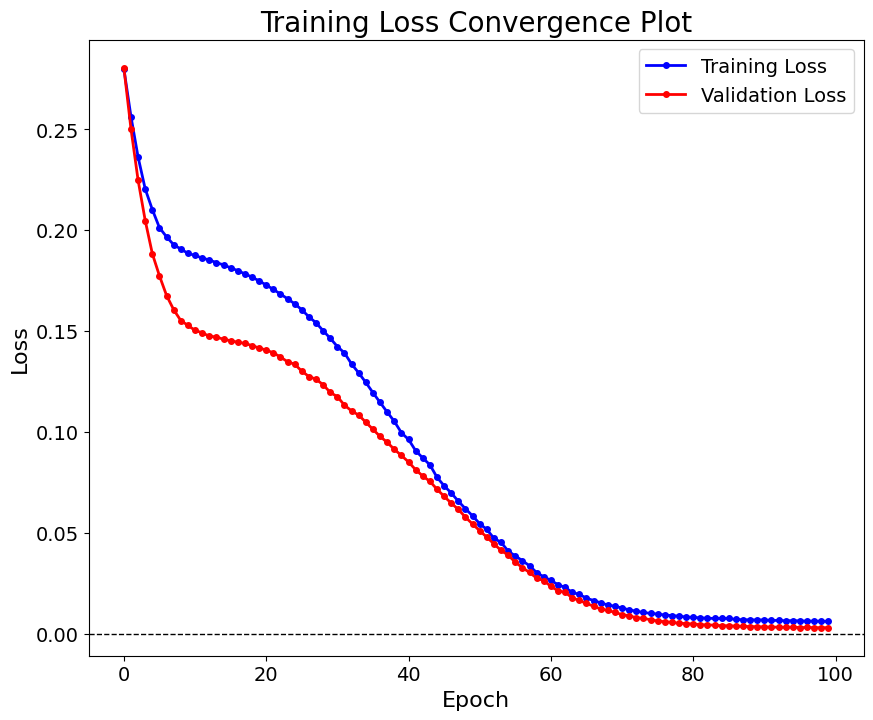

In [22]:
# Plotting the training and validation loss convergence
plt.figure(figsize=(10, 8))
plt.plot(model_reg_training_loss['train_loss'], 
         color='blue', marker='o', markersize=4, linestyle='-', linewidth=2, 
         label='Training Loss')
plt.plot(model_reg_training_loss['val_loss'], 
         color='red', marker='o', markersize=4, linestyle='-', linewidth=2,
         label='Validation Loss')
plt.xlabel('Epoch', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.title('Training Loss Convergence Plot', fontsize=20)
plt.legend(fontsize=14)
# plt.xticks(range(0, num_epochs)) 
plt.tick_params(axis='both', which='major', labelsize=14)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Save the figure
plt.savefig(save_dir+"model_reg_train_loss_conv_plot.png", format='png', dpi=300)

# Show the plot
plt.show()

In [23]:
# Save the PyTorch model parameters
torch.save(model_reg.state_dict(), save_dir+'model_reg_params.pth')

# Testing the PyTorch neural network model
- Using the predefined model object **model_reg_eval**, we evaluate our trained model.

In [24]:
# Load model for evaluation with saved parameters
model_reg_eval.load_state_dict(torch.load(save_dir+'model_reg_params.pth', weights_only=True))

<All keys matched successfully>

## Evaluate Neural Network Model

### Evaluate Neural Network Model

- Categorical outcome performance metrics:

- Numerical outcome perofrmance metrics:
    - MAE (mean absolute error): measures the average of the absolute errors
    $$MAE = \frac{1}{n}\sum_{i=1}^{n}{| Y_i - \hat{Y_i} |}$$

    - MSE (mean squared error): measures the average of the sqaures of the errors
    $$MSE = \frac{1}{n}\sum_{i=1}^{n}{(Y_i - \hat{Y_i})^2}, \quad \text{where } n\text{: num. of data points, } Y\text{: observed values of the variable being predicted, } \hat{Y}\text{: being the predicted values.}$$

    - RMSE (root mean squared error): sqaured root of MSE
    $$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}{(Y_i - \hat{Y_i})^2}}$$

    - R-squsred (the coefficient of determination):  
    $$R^2 = 1 - \frac{SSE}{SST} = 1 - \frac{\sum_{i=1}^{n}{(Y_i - \hat{Y})^2}}{\sum_{i=1}^{n}{(Y_i - \overline{Y})^2}}$$
    
    - Adjusted R-squared: 
    $$R^2_{adj} = 1 - \frac{SSE / df_{res}}{SST / df_{total}} = 1- (1- R^2)\frac{(n-1)}{(n-p-1)}, \quad \text{where } n\text{: num. of data points, } p\text{: the num. of variables in the model.}$$

In [25]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

def model_performance(model, data_loader):
    model.eval()  # set model to evaluation mode
    
    if isinstance(loss_func, nn.MSELoss):
        with torch.no_grad():
            total_loss = 0
            num_samples = 0
            all_targets = []
            all_predictions = []
            
            for batch_idx, (data, target) in enumerate(data_loader):
                # Get the predicted target value and the true target value
                data = data.squeeze()
                target = target.float()
                output = model(data)
                pred = output.squeeze()

                # Calculate the loss
                loss = loss_func(pred, target)
                total_loss += loss.item() * data.size(0)
                num_samples += data.size(0)

                # Collect all targets and predictions for further metrics calculation
                all_targets.extend(target.tolist())
                all_predictions.extend(pred.tolist())
                
            # Calculate MSE and R-squared
            y_true = np.array(all_targets)
            y_pred = np.array(all_predictions)
            
            mse_loss = mean_squared_error(y_true=y_true, y_pred=y_pred)
            rmse_loss = root_mean_squared_error(y_true=y_true, y_pred=y_pred)
            mae_loss = mean_absolute_error(y_true=y_true, y_pred=y_pred)
            
            r_squared = r2_score(y_true=y_true, y_pred=y_pred)
            r_sqaured_adj = 1-(1-r_squared)*((len(data_loader.dataset)-1)/(len(data_loader.dataset)-len(data[1])-1))
            
            
            # Print results
            print('num_samples:', num_samples)
            print(
                "Performance on the given data:\n\tMAE loss: {:.8f}\n\tMSE loss: {:.8f}\n\tRMSE loss: {:.8f}\n\tR-squared: {:.8f}\n\tAdj R-squared: {:.8f}".format(
                    mae_loss, mse_loss, rmse_loss, r_squared, r_sqaured_adj
                )
            )
            
        results = {
            'y_true': y_true,
            'y_pred': y_pred,
            'num_samples': num_samples,
            'mae': mae_loss,
            'mse': mse_loss,
            'rmse': rmse_loss,
            'r-squared': r_squared,
            'adj r-squared': r_sqaured_adj
            }
    return results

In [26]:
print(f'---Model Performance on Training Dataset---')
model_reg_train_result = model_performance(model_reg_eval, train_loader)

---Model Performance on Training Dataset---
num_samples: 100
Performance on the given data:
	MAE loss: 0.05342809
	MSE loss: 0.00608130
	RMSE loss: 0.07798272
	R-squared: 0.96708514
	Adj R-squared: 0.96569925


In [27]:
print(f'-----Model Performance on Test Dataset-----')
model_reg_test_result  = model_performance(model_reg_eval, test_loader)

-----Model Performance on Test Dataset-----
num_samples: 20
Performance on the given data:
	MAE loss: 0.04209576
	MSE loss: 0.00302086
	RMSE loss: 0.05496239
	R-squared: 0.97737494
	Adj R-squared: 0.97134159


In [28]:
# Save the model performance into .txt file
with open(save_dir+f'model_reg_perf_output_train.txt', "w") as file:
    for key, value in model_reg_train_result.items():
        file.write(f"{key}: {value}\n")
        
with open(save_dir+f'model_reg_perf_output_test.txt', "w") as file:
    for key, value in model_reg_test_result.items():
        file.write(f"{key}: {value}\n")

## Plot the residual plot of the neural network model

In [29]:
import torch
import matplotlib.pyplot as plt

actuals = []
predictions = []

with torch.no_grad():
    for data, target in test_loader:
        # Assuming your data doesn't need squeezing or other preprocessing
        output = model_reg(data).squeeze()  # Get model predictions
        actuals.extend(target.numpy())  # Store actual values
        predictions.extend(output.numpy())  # Store predictions

# Compute residuals
residuals = [actual - predicted for actual, predicted in zip(actuals, predictions)]

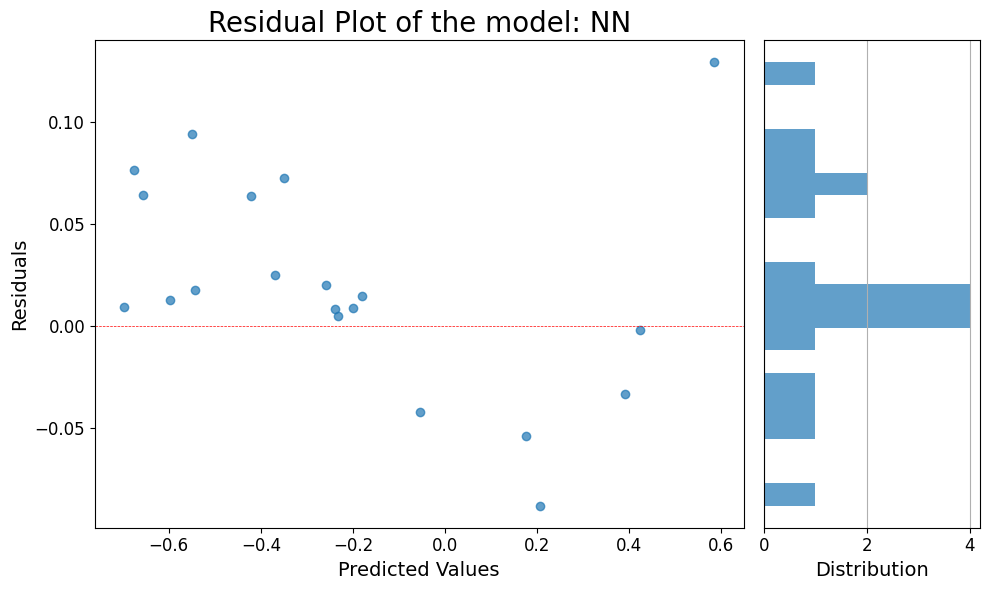

In [30]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

residuals = [t - p for t, p in zip(actuals, predictions)]

# Create a grid for the subplots
fig = plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
gs = GridSpec(1, 2, width_ratios=[3, 1])

# Create the scatter plot on the left
ax0 = fig.add_subplot(gs[0])
ax0.scatter(predictions, residuals, alpha=0.7)
ax0.axhline(y=0, color='red', linestyle='--', linewidth=0.5)
ax0.set_xlabel('Predicted Values', fontsize=14)
ax0.set_ylabel('Residuals', fontsize=14)
ax0.set_title('Residual Plot of the model: NN', fontsize=20)
ax0.tick_params(axis='both', which='major', labelsize=12)

# Create the histogram on the right
ax1 = fig.add_subplot(gs[1], sharey=ax0)
ax1.hist(residuals, orientation='horizontal', bins=20, alpha=0.7)
ax1.set_xlabel('Distribution', fontsize=14)
ax1.grid(True)
ax1.yaxis.set_visible(False)  # Hide the y-axis labels for the histogram
ax1.tick_params(axis='x', which='major', labelsize=12)

# Adjust the layout
plt.tight_layout()

# Save the figure
plt.savefig(save_dir+"model_reg_residual_plot.png", format='png', dpi=300)

# Show the plot
plt.show()

# Model comparison: linear regression, and random forest model

Model Name: LinearRegression

-----Model Performance on Training Dataset-----
Mean Squared Error (MSE): 1.6652360671149796e-31
Root Mean Squared Error (RMSE): 4.0807304090260354e-16
Mean Absolute Error (MAE): 3.252953462151709e-16
R^2 Score of the train data: 1.0
Adj. R^2 Score of the train data: 1.0

-----Model Performance on Test Dataset-----
Mean Squared Error (MSE): 2.0954117794933126e-31
Root Mean Squared Error (RMSE): 4.577566798522237e-16
Mean Absolute Error (MAE): 4.1078251911130794e-16
R^2 Score of the test data: 1.0
Adj. R^2 Score of the test data: 1.0



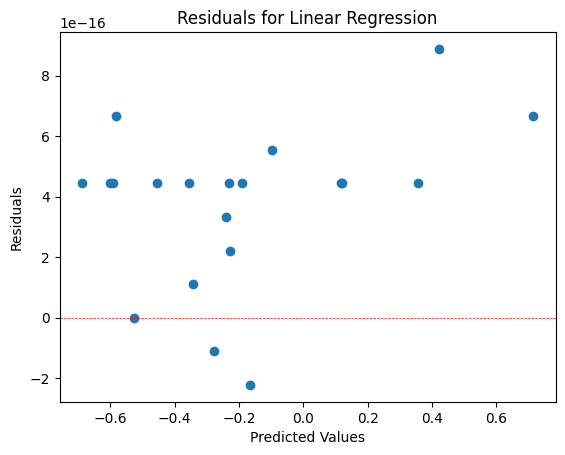

Model Name: RandomForestRegressor

-----Model Performance on Training Dataset-----
Mean Squared Error (MSE): 0.0032818304937832976
Root Mean Squared Error (RMSE): 0.05728726292801304
Mean Absolute Error (MAE): 0.04408768418506322
R^2 Score of the train data: 0.9822371990641684
Adj. R^2 Score of the train data: 0.9775004521479467

-----Model Performance on Test Dataset-----
Mean Squared Error (MSE): 0.028001995725290368
Root Mean Squared Error (RMSE): 0.1673379685704663
Mean Absolute Error (MAE): 0.13179870102419727
R^2 Score of the test data: 0.7902762589042335
Adj. R^2 Score of the test data: 0.7343499279453625



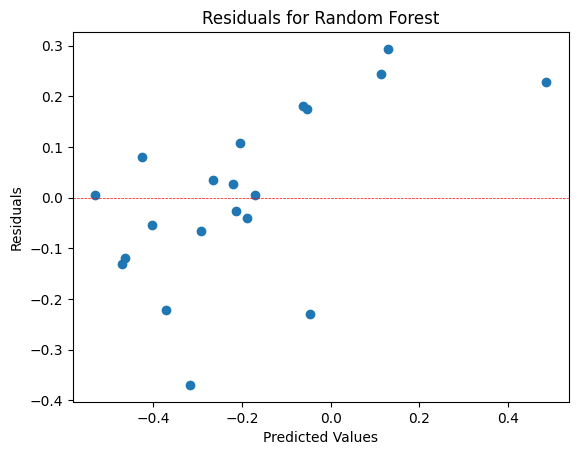

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# # Split the data into training and testing sets
# X_data = data.drop('target', axis=1)
# y_data = data['target']

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the LinearRegression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the train / test data
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate the model
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
adj_r2_train = 1-(1-r2_train)*((len(X_test)-1)/(len(X_test)-len(X_test[0])-1))

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
adj_r2_test = 1-(1-r2_test)*((len(X_test)-1)/(len(X_test)-len(X_test[0])-1))


print(f"Model Name: {model.__class__.__name__}\n")
print(f'-----Model Performance on Training Dataset-----')
print(f"Mean Squared Error (MSE): {mse_train}")
print(f"Root Mean Squared Error (RMSE): {rmse_train}")
print(f"Mean Absolute Error (MAE): {mae_train}")
print(f"R^2 Score of the train data: {r2_train}")
print(f"Adj. R^2 Score of the train data: {adj_r2_train}\n")
print(f'-----Model Performance on Test Dataset-----')
print(f"Mean Squared Error (MSE): {mse_test}")
print(f"Root Mean Squared Error (RMSE): {rmse_test}")
print(f"Mean Absolute Error (MAE): {mae_test}")
print(f"R^2 Score of the test data: {r2_test}")
print(f"Adj. R^2 Score of the test data: {adj_r2_test}\n")


# Residual plot for Linear Regression
plt.scatter(y_pred_test, y_test - y_pred_test)
plt.title("Residuals for Linear Regression")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.5)
plt.show()

# Initialize and fit the RandomForestRegressor model
model2 = RandomForestRegressor(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

# Predict on the test data
y_pred = model2.predict(X_test)

# Predict on the train / test data
y_pred_train = model2.predict(X_train)
y_pred_test = model2.predict(X_test)

# Evaluate the model
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)
adj_r2_train = 1-(1-r2_train)*((len(X_test)-1)/(len(X_test)-len(X_test[0])-1))

mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)
adj_r2_test = 1-(1-r2_test)*((len(X_test)-1)/(len(X_test)-len(X_test[0])-1))


print(f"Model Name: {model2.__class__.__name__}\n")
print(f'-----Model Performance on Training Dataset-----')
print(f"Mean Squared Error (MSE): {mse_train}")
print(f"Root Mean Squared Error (RMSE): {rmse_train}")
print(f"Mean Absolute Error (MAE): {mae_train}")
print(f"R^2 Score of the train data: {r2_train}")
print(f"Adj. R^2 Score of the train data: {adj_r2_train}\n")
print(f'-----Model Performance on Test Dataset-----')
print(f"Mean Squared Error (MSE): {mse_test}")
print(f"Root Mean Squared Error (RMSE): {rmse_test}")
print(f"Mean Absolute Error (MAE): {mae_test}")
print(f"R^2 Score of the test data: {r2_test}")
print(f"Adj. R^2 Score of the test data: {adj_r2_test}\n")

# Residual plot for Linear Regression
plt.scatter(y_pred_test, y_test - y_pred_test)
plt.title("Residuals for Random Forest")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.5)
plt.show()